In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [4]:
#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Sample'] = pd.to_numeric(df['Sample'], errors='coerce')
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None
    
def graficar_datos(df, columna_x, columna_y):
    
    plt.figure(figsize=(8, 5))
    plt.plot(df[columna_x], df[columna_y], marker='', linestyle='-')
    plt.xlabel(columna_x)
    plt.ylabel(columna_y)
    plt.title(f"Gráfica de {columna_y} vs {columna_x}")
    plt.grid()
    plt.show()


def graficar_multiples_dfs(lista_dfs, nombres, columna_x, columna_y):
    
    plt.figure(figsize=(8, 5))
    for df, nombre in zip(lista_dfs, nombres):
        if df is not None and columna_x in df.columns and columna_y in df.columns:
            plt.plot(df[columna_x], df[columna_y], marker='', linestyle='-', markersize=3, linewidth=0.8, label=nombre)
        else:
            print(f"Error: No se pudo graficar {nombre}, columnas no encontradas")
    plt.xlabel(columna_x)
    plt.ylabel(columna_y)
    plt.title(f"Gráfica de {columna_y} vs {columna_x} de los 4 espectrómetros")
    plt.legend()
    plt.minorticks_on()  # Habilitar las marcas menores
    plt.grid(which='both', linestyle='-', linewidth=0.5, alpha=0.7)
    # Ajustar los márgenes de manera manual
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)
    plt.show()

In [5]:
#Leer archivos

UV1 = "20250321_Ti_Reference_A02\Ti_ReferenceA02_shot2_7324767SP.txt" 
UV2 = "20250321_Ti_Reference_A02\Ti_ReferenceA02_shot2_7324768SP.txt" 
VIS = "20250321_Ti_Reference_A02\Ti_ReferenceA02_shot2_7324769SP.txt" 
NIR = "20250321_Ti_Reference_A02\Ti_ReferenceA02_shot2_7324770SP.txt" 

datos_UV1 = leer_archivo_txt(UV1)
datos_UV2 = leer_archivo_txt(UV2)
datos_VIS = leer_archivo_txt(VIS)
datos_NIR = leer_archivo_txt(NIR)


In [6]:
#Declaración de los intervalos de solapamiento

wls_UV1 = datos_UV1['Wave']
wls_UV2 = datos_UV2['Wave']
wls_VIS = datos_VIS['Wave']
wls_NIR = datos_NIR['Wave']
i1 = (wls_UV2[0], wls_UV1[len(wls_UV1)-1])
i2 = (wls_VIS[0], wls_UV2[len(wls_UV2)-1])
i3 = (wls_NIR[0], wls_VIS[len(wls_VIS)-1])


In [7]:
#Aislamiento de los intervalos de solapamiento

datos_UV1_fil1 = datos_UV1[(datos_UV1['Wave'] >= i1[0]) & (datos_UV1['Wave'] <= i1[1])]
datos_UV2_fil1 = datos_UV2[(datos_UV2['Wave'] >= i1[0]) & (datos_UV2['Wave'] <= i1[1])]

datos_UV2_fil2 = datos_UV2[(datos_UV2['Wave'] >= i2[0]) & (datos_UV2['Wave'] <= i2[1])]
datos_VIS_fil2 = datos_VIS[(datos_VIS['Wave'] >= i2[0]) & (datos_VIS['Wave'] <= i2[1])]

datos_VIS_fil3 = datos_VIS[(datos_VIS['Wave'] >= i3[0]) & (datos_VIS['Wave'] <= i3[1])]
datos_NIR_fil3 = datos_NIR[(datos_NIR['Wave'] >= i3[0]) & (datos_NIR['Wave'] <= i3[1])]

In [8]:
#Extracción de las medianas

mediana_UV1_fil1 = datos_UV1_fil1['Sample'].median()
mediana_UV2_fil1 = datos_UV2_fil1['Sample'].median()

mediana_UV2_fil2 = datos_UV2_fil2['Sample'].median()
mediana_VIS_fil2 = datos_VIS_fil2['Sample'].median()

mediana_VIS_fil3 = datos_VIS_fil3['Sample'].median()
mediana_NIR_fil3 = datos_NIR_fil3['Sample'].median()


In [9]:
#Cálculo de los coeficientes

coef1 = mediana_UV1_fil1/mediana_UV2_fil1
coef2 = mediana_UV2_fil2/mediana_VIS_fil2
coef3 = mediana_VIS_fil3/mediana_NIR_fil3

coef3

np.float64(1.497445906713325)

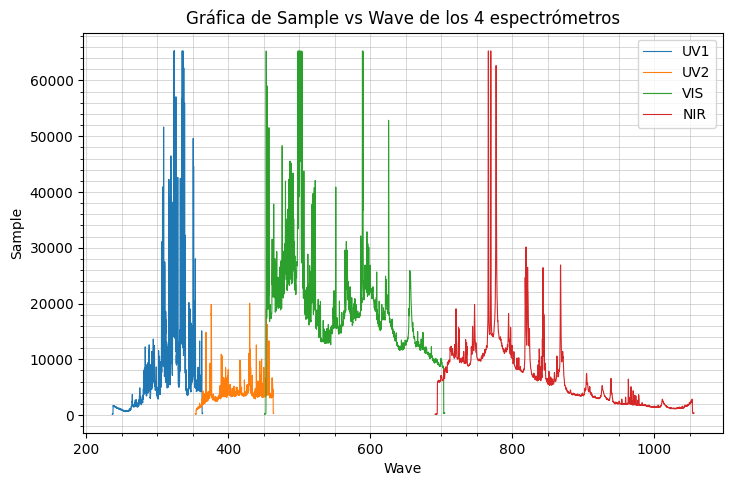

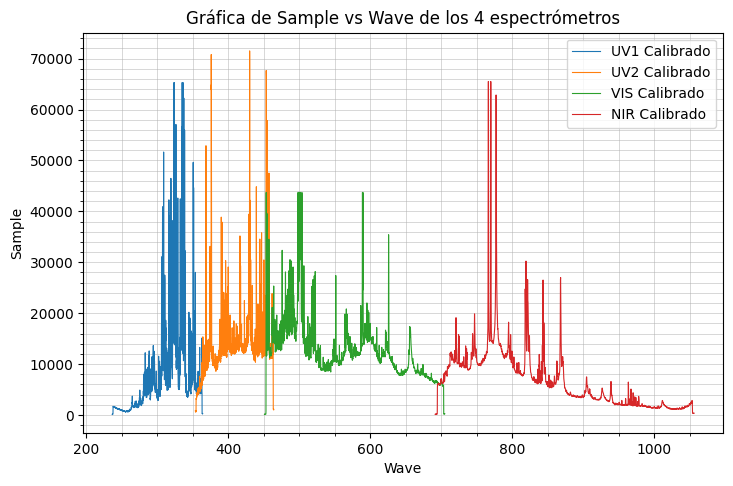

In [ ]:
#Corrección del offset

datos_UV1_corr = datos_UV1.copy()
datos_UV2_corr = datos_UV2.copy()
datos_VIS_corr = datos_VIS.copy()
datos_NIR_corr = datos_NIR.copy()


datos_UV1_corr['Sample'] = datos_UV1_corr['Sample']
datos_UV2_corr['Sample'] = datos_UV2_corr['Sample']*coef1
datos_VIS_corr['Sample'] = datos_VIS_corr['Sample']*coef2*coef1
datos_NIR_corr['Sample'] = datos_NIR_corr['Sample']*coef3*coef2*coef1

#### TO DO: ELIMINAR PRIMEROS Y ÚLTIMOS 16 DATOS


dfs_calibrados = [datos_UV1_corr, datos_UV2_corr, datos_VIS_corr, datos_NIR_corr]
nombres_calibrados = ["UV1 Calibrado", "UV2 Calibrado", "VIS Calibrado", "NIR Calibrado"]
dfs = [datos_UV1, datos_UV2, datos_VIS, datos_NIR]
nombres = ["UV1", "UV2", "VIS", "NIR"]
graficar_multiples_dfs(dfs, nombres, 'Wave', 'Sample')
graficar_multiples_dfs(dfs_calibrados, nombres_calibrados, 'Wave', 'Sample')




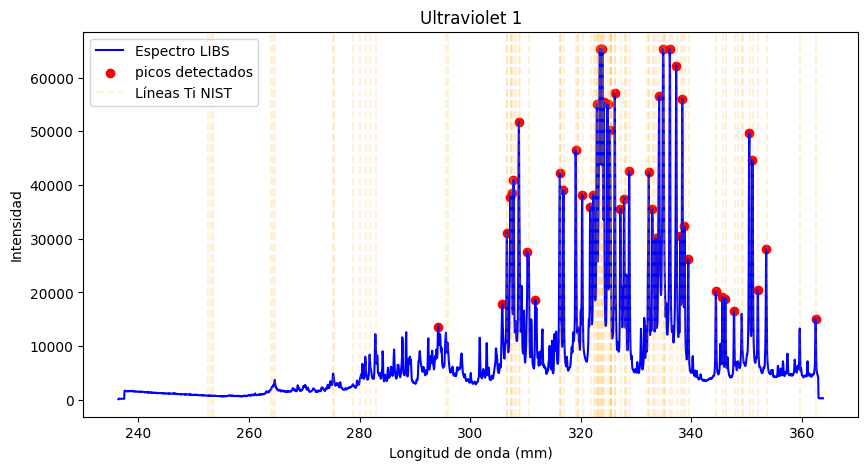

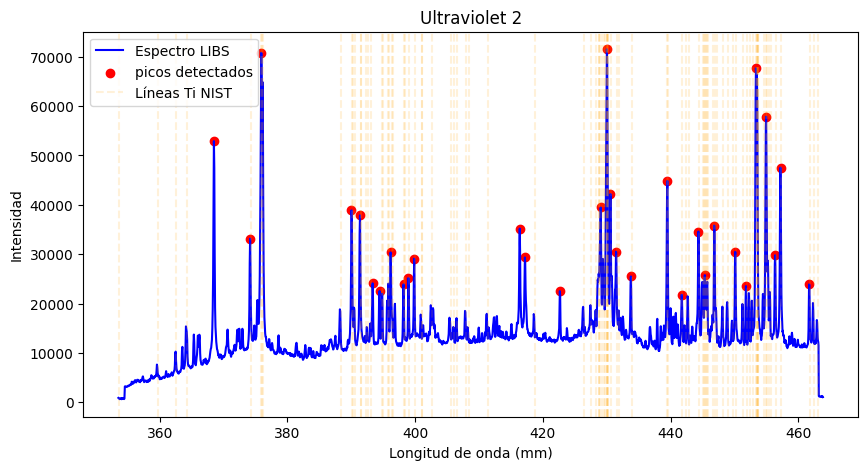

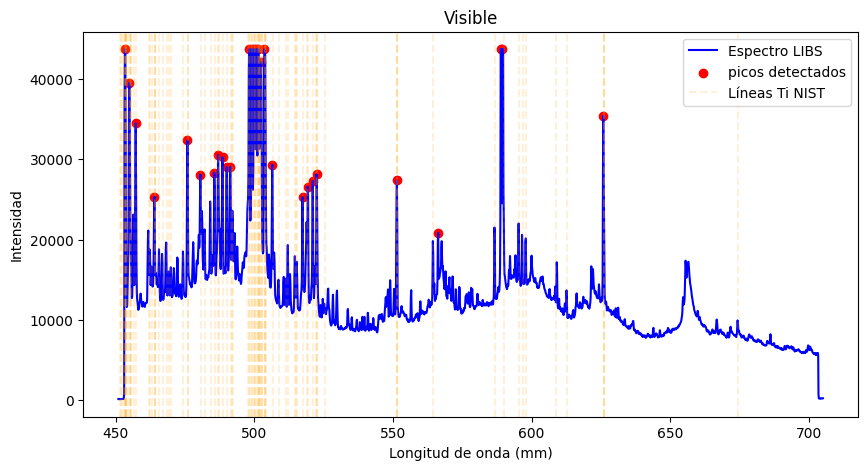

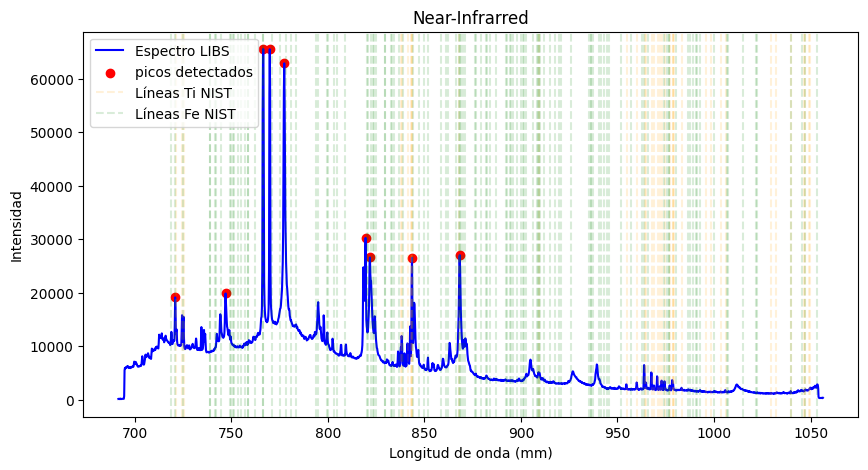

: 

In [ ]:
# Extracción de las longitudes de onda donde se hallan los picos

wls_UV1 = datos_UV1['Wave']
wls_UV2 = datos_UV2['Wave']
wls_VIS = datos_VIS['Wave']
wls_NIR = datos_NIR['Wave']
counts_UV1 = datos_UV1_corr['Sample']
counts_UV2 = datos_UV2_corr['Sample']
counts_VIS = datos_VIS_corr['Sample']
counts_NIR = datos_NIR_corr['Sample']

#Extracción de las longitudes de onda pico
picos_UV1, propiedades = find_peaks(counts_UV1, prominence=10000,
                                                 height=10000,
                                                 distance=1)
longitudes_pico_UV1 = wls_UV1[picos_UV1]
counts_pico_UV1 = propiedades['peak_heights']

picos_UV2, propiedades = find_peaks(counts_UV2, prominence=10000,
                                                 height=10000,
                                                 distance=1)
longitudes_pico_UV2 = wls_UV2[picos_UV2]
counts_pico_UV2 = propiedades['peak_heights']

picos_VIS, propiedades = find_peaks(counts_VIS, prominence=10000,
                                                 height=10000,
                                                 distance=1)
longitudes_pico_VIS = wls_VIS[picos_VIS]
counts_pico_VIS = propiedades['peak_heights']

picos_NIR, propiedades = find_peaks(counts_NIR, prominence=10000,
                                                 height=10000,
                                                 distance=1)
longitudes_pico_NIR = wls_NIR[picos_NIR]
counts_pico_NIR = propiedades['peak_heights']



from astroquery.nist import Nist
import astropy.units as u
wl_min_UV1 = 236.381 * u.nm
wl_max_UV1 = 363.792 * u.nm
wl_min_UV2 = 353.533 * u.nm
wl_max_UV2 = 463.862 * u.nm
wl_min_VIS = 450.961 * u.nm
wl_max_VIS = 705.106 * u.nm
wl_min_NIR = 691.496 * u.nm
wl_max_NIR = 1056.420 * u.nm

result1 = Nist.query(wl_min_UV1, wl_max_UV1, linename="Ti")
filtered_result1 = result1[(result1["Spectrum"] == "Ti I") | (result1["Spectrum"] == "Ti II")]
filtered_result1["Rel."] = pd.to_numeric(filtered_result1["Rel."], errors="coerce")
filtered_result1 = filtered_result1[filtered_result1["Rel."] > 500]  # Ajusta el umbral según tu espectro

result2 = Nist.query(wl_min_UV2, wl_max_UV2, linename="Ti")
filtered_result2 = result2[(result2["Spectrum"] == "Ti I") | (result2["Spectrum"] == "Ti II")]
filtered_result2["Rel."] = pd.to_numeric(filtered_result2["Rel."], errors="coerce")
filtered_result2 = filtered_result2[filtered_result2["Rel."] > 500]  # Ajusta el umbral según tu espectro

result3 = Nist.query(wl_min_VIS, wl_max_VIS, linename="Ti")
filtered_result3 = result3[(result3["Spectrum"] == "Ti I") | (result3["Spectrum"] == "Ti II")]
filtered_result3["Rel."] = pd.to_numeric(filtered_result3["Rel."], errors="coerce")
filtered_result3 = filtered_result3[filtered_result3["Rel."] > 500]  # Ajusta el umbral según tu espectro

result4 = Nist.query(wl_min_NIR, wl_max_NIR, linename="Ti")
#filtered_result4 = result4[(result4["Spectrum"] == "Ti I") | (result4["Spectrum"] == "Ti II") | (result4["Spectrum"] == "Ti III")]
filtered_result4 = result4
filtered_result4["Rel."] = pd.to_numeric(filtered_result4["Rel."], errors="coerce")
filtered_result4 = filtered_result4[filtered_result4["Rel."] > 500]  # Ajusta el umbral según tu espectro

resultAl = Nist.query(wl_min_NIR, wl_max_NIR, linename="Fe")
filtered_resultAl = resultAl[(resultAl["Spectrum"] == "Fe I")]
filtered_resultAl["Rel."] = pd.to_numeric(filtered_resultAl["Rel."], errors="coerce")
filtered_resultAl = filtered_resultAl[filtered_resultAl["Rel."] > 500]  # Ajusta el umbral según tu espectro


plt.figure(figsize=(10,5))
plt.plot(wls_UV1, counts_UV1, label="Espectro LIBS", color="blue")
plt.scatter(longitudes_pico_UV1, counts_pico_UV1, color="red", label = "picos detectados")

#print(filtered_result)
for wl in filtered_result1["Observed"]:
    plt.axvline(x = wl, color="orange", linestyle="--",alpha = 0.15, label="Líneas Ti NIST" if "Líneas Ti NIST" not in plt.gca().get_legend_handles_labels()[1] else "")

plt.xlabel("Longitud de onda (mm)")
plt.ylabel("Intensidad")
plt.title("Ultraviolet 1")
plt.legend()
plt.show()


plt.figure(figsize=(10,5))
plt.plot(wls_UV2, counts_UV2, label="Espectro LIBS", color="blue")
plt.scatter(longitudes_pico_UV2, counts_pico_UV2, color="red", label = "picos detectados")

#print(filtered_result)
for wl in filtered_result2["Observed"]:
    plt.axvline(x = wl, color="orange", linestyle="--",alpha = 0.15, label="Líneas Ti NIST" if "Líneas Ti NIST" not in plt.gca().get_legend_handles_labels()[1] else "")

plt.xlabel("Longitud de onda (mm)")
plt.ylabel("Intensidad")
plt.title("Ultraviolet 2")
plt.legend()
plt.show()


plt.figure(figsize=(10,5))
plt.plot(wls_VIS, counts_VIS, label="Espectro LIBS", color="blue")
plt.scatter(longitudes_pico_VIS, counts_pico_VIS, color="red", label = "picos detectados")

#print(filtered_result)
for wl in filtered_result3["Observed"]:
    plt.axvline(x = wl, color="orange", linestyle="--",alpha = 0.15, label="Líneas Ti NIST" if "Líneas Ti NIST" not in plt.gca().get_legend_handles_labels()[1] else "")

plt.xlabel("Longitud de onda (mm)")
plt.ylabel("Intensidad")
plt.title("Visible")
plt.legend()
plt.show()


plt.figure(figsize=(10,5))
plt.plot(wls_NIR, counts_NIR, label="Espectro LIBS", color="blue")
plt.scatter(longitudes_pico_NIR, counts_pico_NIR, color="red", label = "picos detectados")

#print(filtered_result)
for wl in filtered_result4["Observed"]:
    plt.axvline(x = wl, color="orange", linestyle="--",alpha = 0.15, label="Líneas Ti NIST" if "Líneas Ti NIST" not in plt.gca().get_legend_handles_labels()[1] else "")

for wl in filtered_resultAl["Observed"]:
    plt.axvline(x = wl, color="Green", linestyle="--",alpha = 0.15, label="Líneas Fe NIST" if "Líneas Fe NIST" not in plt.gca().get_legend_handles_labels()[1] else "")

plt.xlabel("Longitud de onda (mm)")
plt.ylabel("Intensidad")
plt.title("Near-Infrarred")
plt.legend()
plt.show()